# Fiery results - epochs

## NB y- and x-axis should be inverted

In [1]:
# imports

import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import log_loss
import pickle
import torch.nn.functional as F


In [2]:
from helper import get_results, find_gaussians, find_gaussians_cal, get_models_in_rings, find_instance_centers, plot_seg, \
                   generate_rel_diagrams, get_clusters, plot_img

## 0. Helper functions and static variables

In [3]:
PATH_labels_pedestrians = "labels_val_epoch0_pedestrians"  # Folder name
PATH_res_pedestrians = "results_val_epoch1_pedestrians_e12" # Folder name

PATH_labels_vehicles = "labels_val"
PATH_res_vehicles = "results_val"

PATH_image = "images_val" # Folder name

FILE_label = "labels_val_%i.p"   # Single file name
FILE_res = "results_val_img%i.p"  # Single file name
FILE_image = "image_val_b%i_i%i_s%i_c%i.jpg"  # Single file name

In [4]:
from PIL import Image
import matplotlib as mpl
from os.path import join

def get_img(b, i, s, c):
    file_img = FILE_image  % (b, i, s, c)
        
    return Image.open(join(PATH_image, file_img))

def plot_img(bat, ix, seq = 2):

    # Plot present RGB frames and predictions
    val_w = 2.99
    cameras = ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT']
    image_ratio = (224, 480)[0] / (224, 480)[1]
    val_h = val_w * image_ratio
    fig = plt.figure(figsize=(4 * val_w, 2 * val_h))
    width_ratios = (val_w, val_w, val_w, val_w)
    gs = mpl.gridspec.GridSpec(2, 4, width_ratios=width_ratios)
    gs.update(wspace=0.0, hspace=0.0, left=0.0, right=1.0, top=1.0, bottom=0.0)

    for i in range(6):

        ax = plt.subplot(gs[i // 3, i % 3])
        showimg = get_img(bat,ix,seq,i) 

        if i > 2:
            showimg = showimg.transpose(Image.FLIP_LEFT_RIGHT)

        plt.imshow(showimg)

        plt.annotate(cameras[i].replace('_', ' ').replace('CAM ', ''), (0.01, 0.87), c='white',
                         xycoords='axes fraction', fontsize=14)

        plt.axis('off')

    plt.show()

In [5]:
get_img(idx//4, idx%4,2,1)

NameError: name 'idx' is not defined

<Figure size 1440x1280 with 0 Axes>

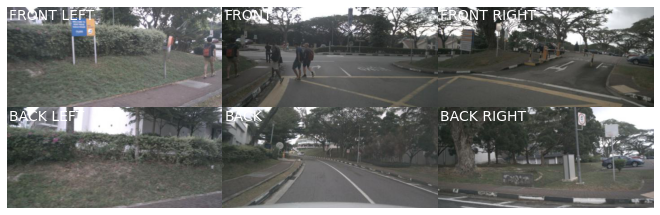

In [6]:
idx = 628
plt.figure(figsize=(18, 16), dpi=80)
plot_img(idx//4, idx%4)

## 1. Get  all results from data

### Generate data for pedestrians

In [7]:
if False:

    segm_ped_y, segm_ped_p, segm_ped_log, inst_ped_y = get_results(PATH_labels_pedestrians,
                                                                   PATH_res_pedestrians,
                                                                   flip_input=True) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("segm_results_pedestrains_e12_full_inst.npz", y=segm_ped_y, p=segm_ped_p, log=segm_ped_log, inst=inst_ped_y)

else:
    segm_ped_data = np.load("segm_results_pedestrains_e12_full_inst.npz")

    segm_ped_y = segm_ped_data["y"]
    segm_ped_p = segm_ped_data["p"]

In [8]:
inst_ped_y = segm_ped_data["inst"]

In [9]:
if False:

    center_ped_y, center_ped_p, _, _ = get_results(PATH_labels_pedestrians,
                                                   PATH_res_pedestrians,
                                                    results_name = "instance_center", label_name = "centerness", 
                                                   flip_input=True, use_softmax = False) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("center_results_pedestrains_e12_full.npz", y=center_ped_y, p=center_ped_p)

else:
    center_ped_data = np.load("center_results_pedestrains_e12_full.npz")

    center_ped_y = segm_ped_data["y"]
    center_ped_p = center_ped_data["p"]

In [10]:
segm_ped_y.shape

(5, 5119, 200, 200)

In [11]:
segm_ped_p.shape

(5, 5119, 200, 200)

In [12]:
center_ped_p.shape

(5, 5119, 200, 200)

In [13]:
inst_ped_y.shape

(5, 5119, 200, 200)

## 2. Generate input data from segmentation

### Match segmentation and norm-distribution

## Presence Uncertainty

#### Reliability diagrams

## Pixel-wise calibration

In [14]:
nr_future = 0

In [15]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split


def get_model_cal(p, y, Cal_Fn = IsotonicRegression, nr_future = 0, test_size = 0.8, random_state = 828):

    # 20% for validation (calibration modelling)
    indices_val, indices_test = train_test_split(np.arange(0, p.shape[1]), test_size=test_size, random_state=random_state)

    models = []
    
    masks = [np.ones((200, 200), dtype="bool")]
    
    segm_ped_p_val = p[nr_future, indices_val,]
    segm_ped_y_val = y[nr_future, indices_val,]

    for i, m in enumerate(masks):

        print(i)

        ys_pxl = segm_ped_y_val.reshape(-1) 
        preds_pxl = segm_ped_p_val.reshape(-1)

        print(preds_pxl.shape)
        
        model = Cal_Fn()
        model.fit(preds_pxl, ys_pxl)

        models.append(model)
        
    return models, masks, (indices_val, indices_test)

In [16]:
models_cal, masks_cal, (indices_val, indices_test) = get_model_cal(segm_ped_p, segm_ped_y, nr_future = nr_future, random_state=1001)

0
(40920000,)


In [17]:
models_cal_c, masks_cal_c, (indices_val, indices_test) = get_model_cal(center_ped_p, center_ped_y, nr_future = nr_future, random_state=1001)

0
(40920000,)


In [18]:
indices_val, indices_test = train_test_split(np.arange(0, segm_ped_p.shape[1]), test_size=0.8, random_state=1001)

In [19]:
segm_ped_p[nr_future, indices_test,].reshape(-1).shape

(163840000,)

In [20]:
if False:  # No ring-wise calibration used
    models_cal, masks_cal, (indices_val, indices_test) = \
        get_models_in_rings(segm_ped_p, segm_ped_y, nr_future = nr_future, random_state=1001)
    models_cal_c, masks_cal_c, (indices_val_c, indices_test_c) =  \
        get_models_in_rings(center_ped_p, center_ped_y, nr_future = nr_future, random_state=1001)

In [100]:
nr_future = 0

idx = 630
val_pixels = 40920000

if True:  # Skip if no need to rerun
    
    areas = [np.array([[59,101],[94,106]]), np.array([[59,101],[82,94]]), np.array([[59,101],[106,118]]), 
             np.array([[17,59],[94,106]]), np.array([[17,59],[82,94]]), np.array([[17,59],[106,118]])]


    ys_front = []
    prob_front = []
    prob_cal_front = []
    
    prob_front_max = []
    prob_cal_front_max = []
    
    prob_front_mean = []
    prob_cal_front_mean = []
    
    indices = []


    for idx in [idx]:
        
        #print(idx)

        if idx % 100 == 0:
            print(idx)

        segm_cal_full = np.zeros(shape=masks_cal[0].shape)
        center_cal_full = np.zeros(shape=masks_cal_c[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)
            
            segm_cal_2d[np.isnan(segm_cal_2d)] = 1/val_pixels
            segm_cal_2d = np.clip(segm_cal_2d, 1/val_pixels, 1)
            segm_cal_2d = segm_cal_2d.astype("float64")

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))

            segm_cal_full[mask] = segm_cal_2d[mask]


        segm_p_new = segm_ped_p[nr_future, idx].copy()
        center_ped_p_new = center_ped_p[nr_future, idx].copy()
        segm_p_cal_new = segm_cal_full.copy()

        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_new, segm_p_cal_new, center_ped_p_new, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3,
                                                            seed=101)
        cls = get_clusters(segm_ped_y[0, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

            
        # Background of GMMs
        background_gmm = np.ones_like(segm_p_cal_new)
        


        if masks_gmm != None:
            
            for m in masks_gmm:
                background_gmm[m] = 0
                
            background_gmm = background_gmm.T
            
            for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

                #print(pred_cl)

                all_matches.append([[], [], [pr], [pr_cal], [dist.mean], [idx]])

                for n_cl, cl in enumerate(cls):
                    matches = np.sum(m[np.array(cl)[:, 1], np.array(cl)[:, 0]]) # kluster transponeeritud
                    match_prob = matches/len(cl)

                    if matches != 0:
                        all_matches[i][0].append(n_cl)
                        all_matches[i][1].append(match_prob)                  
                
        # Get TPs and FNs
        TPs = []

        for am in all_matches:
            TPs += am[0]

        cl_nrs = np.arange(len(cls))
        FNs = cl_nrs[~np.in1d(cl_nrs, TPs)]
        
        
        for area_infront in areas:
        
            mask_infront = background_gmm[area_infront[0,0]:area_infront[0,1], area_infront[1,0]:area_infront[1,1]]
            y_front = 0

            mask_full = np.zeros_like(segm_p_cal_new)
            mask_full[area_infront[0,0]:area_infront[0,1], area_infront[1,0]:area_infront[1,1]] = mask_infront

            for cl_id in FNs:
                cl = cls[cl_id]
                matches = np.sum(mask_full[np.array(cl)[:, 0], np.array(cl)[:, 1]])
                match_prob = matches/len(cl)

                if matches != 0:
                    y_front = 1

            ys_front.append(y_front)
            prob_front.append(np.sum(mask_full*segm_p_new))
            prob_cal_front.append(np.sum(mask_full*segm_p_cal_new))
            indices.append(idx)
        
        #prob_front_max.append(np.max(mask_full*segm_p_new))
        #prob_cal_front_max.append(np.max(mask_full*segm_p_cal_new))
        
        #prob_front_mean.append(np.mean(mask_full*segm_p_new))
        #prob_cal_front_mean.append(np.mean(mask_full*segm_p_cal_new))
        
        # Check if any cls inside for MATCH
        # Get probs for masked area
    
    #np.savez("results_undetected_uncertainty_6m_09_27_22.npz", p=np.array(prob_front), p_cal=np.array(prob_cal_front), y=np.array(ys_front), indices = np.array(indices))

In [101]:
prob_front

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

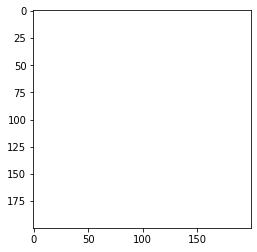

In [91]:
plt.imshow(np.sum([mask_full], axis=0), cmap="hot_r")

In [92]:
factors = 3

gmms = []


for factor in range(1, factors+1):

    pdfs = []
    x, y = np.mgrid[0:segm_p_new.shape[1]:1, 0:segm_p_new.shape[0]:1]
    pos = np.dstack((x, y))

    mask_thresholds = []

    for rv in dists:

        thr = rv.pdf([rv.mean[0] + factor*np.sqrt(rv.cov[0,0]), rv.mean[1] + factor*np.sqrt(rv.cov[1,1])])
        mask_thresholds.append(thr)
        pdfs.append(rv.pdf(pos))

    masks_f = []
    #segm_preds = []
    #distributions
    #segm_preds_cal = []

    for i, pdf in enumerate(pdfs):
        mask = pdf > mask_thresholds[i]
        #segm_preds.append(segm[mask.T].sum())
        #segm_preds_cal.append(segm_cal[mask.T].sum())
        if True:
            print("Pdf:", pdf[mask].sum())
            print("Thresh:", mask_thresholds[i])

        masks_f.append(mask)

    background_gmm = np.ones_like(segm_p_new)

    for m in masks_f:
        background_gmm[m] = 0

    background_gmm = background_gmm.T

    gmms.append(background_gmm)

Pdf: 0.7087999080957176
Thresh: 0.004124898950652912
Pdf: 0.4345233592389011
Thresh: 0.031231404600148276
Pdf: 0.7211156567073675
Thresh: 0.00796753248121305
Pdf: 0.4363290862128286
Thresh: 0.033192967734051664
Pdf: 0.45595650477946315
Thresh: 0.014248436268729302
Pdf: 0.9894443832649659
Thresh: 0.0005728610594990329
Pdf: 0.9557401274151225
Thresh: 0.0015416815567908372
Pdf: 0.4150141301412833
Thresh: 0.0041943453098083755
Pdf: 0.6400933989318353
Thresh: 3.911773573196215e-05
Pdf: 0.4872424493647368
Thresh: 0.03279148261262162
Pdf: 0.9919689470186175
Thresh: 9.6910448399749e-05
Pdf: 0.943180144746447
Thresh: 0.0038881117078613464
Pdf: 0.9953738245274553
Thresh: 0.0001421659284313578
Pdf: 0.9009168624738695
Thresh: 0.006514801005104053
Pdf: 0.8954240207223487
Thresh: 0.0024715922581188916
Pdf: 0.999999986777093
Thresh: 6.362492472240407e-10
Pdf: 0.9999972195087208
Thresh: 9.643573718027469e-08
Pdf: 0.8901397513269835
Thresh: 0.0008149908076794201
Pdf: 0.7785379349678766
Thresh: 4.503795

In [93]:
edge_indices = []

for g in gmms:

    for i in range(g.shape[0]):
        for j in range(g.shape[1]):
            if g[i,j] == 0:
                #print(i, j)
                if g[np.max([0,i-1]),j] == 1:
                    edge_indices.append([i,j])
                elif g[i,np.max([0,j-1])] == 1:
                    edge_indices.append([i,j])
                elif g[i,np.min([199,j+1])] == 1:
                    edge_indices.append([i,j])
                elif g[np.min([199,i+1]),j] == 1:
                    edge_indices.append([i,j])

In [94]:
g_edge = np.zeros([200, 200])
                  

In [95]:
np.array(edge_indices).T.shape

(2, 1078)

In [96]:
for i, j in edge_indices:
    
    g_edge[i,j] = 1

In [97]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

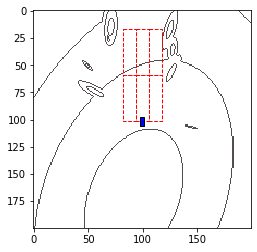

In [98]:
plt.imshow(g_edge, cmap="hot_r", interpolation="nearest", alpha=0.7, zorder=1)

for area in areas:
    rect = Rectangle([area[1,0],area[0,0]],(area[1,1]-area[1,0]),(area[0,1]-area[0,0]),
                      linewidth=1,edgecolor='r',facecolor='none', ls="--")
    plt.gca().add_patch(rect)

rect = Rectangle((97.5,97.5),4,8,linewidth=1,edgecolor='black',facecolor='blue')
plt.gca().add_patch(rect)

    
plt.savefig("res_fig1b_outputs_no_nrs_v2.pdf", bbox_inches='tight')

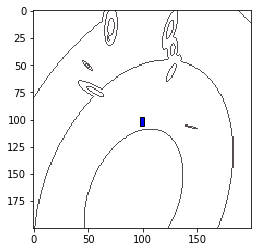

In [99]:
plt.imshow(g_edge, cmap="hot_r", interpolation="nearest", alpha=0.7, zorder=1)

#for area in areas:
#    rect = Rectangle([area[1,0],area[0,0]],(area[1,1]-area[1,0]),(area[0,1]-area[0,0]),
#                      linewidth=1,edgecolor='r',facecolor='none', ls="--")
#    plt.gca().add_patch(rect)

rect = Rectangle((97.5,97.5),4,8,linewidth=1,edgecolor='black',facecolor='blue')
plt.gca().add_patch(rect)

    
plt.savefig("res_fig1b_outputs_no_nrs_no_rect_v2.pdf", bbox_inches='tight')

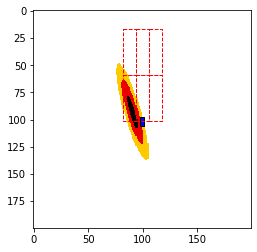

In [61]:
plt.imshow(np.sum([gmms], axis=(0,1)), cmap="hot", interpolation="nearest", alpha=1)

rect = Rectangle((97.5,97.5),4,8,linewidth=1,edgecolor='black',facecolor='blue')
plt.gca().add_patch(rect)

for area in areas:
    rect = Rectangle([area[1,0],area[0,0]],(area[1,1]-area[1,0]),(area[0,1]-area[0,0]),
                      linewidth=1,edgecolor='r',facecolor='none', ls="--")
    plt.gca().add_patch(rect)
    
plt.savefig("res_fig1b_outputs_no_nrs.pdf", bbox_inches='tight')

In [255]:
p, p_cal

(array([5.1051455 , 2.9141762 , 1.6570396 , 0.20972462], dtype=float32),
 array([3.57036905, 1.72194665, 0.94174266, 0.18526603]))

In [256]:
segm_p_temp = segm_ped_p[nr_future, idx].copy()

In [257]:
segm_p_temp[segm_p_temp < 0.1] = 0
segm_p_temp[segm_p_temp >= 0.1] = 1

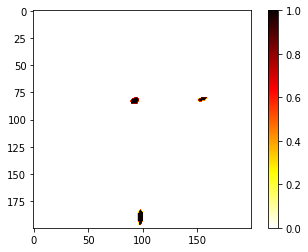

In [258]:
heatmap1 = plt.imshow(segm_p_temp, cmap="hot_r") #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)
#plt.savefig("res_fig1a_segm.pdf", bbox_inches='tight')

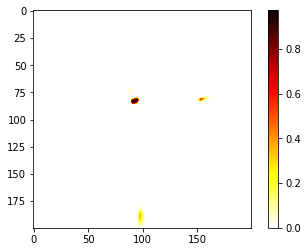

In [259]:
heatmap1 = plt.imshow(segm_ped_p[0, idx], cmap="hot_r") #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)
plt.savefig("res_fig1a_segm.pdf", bbox_inches='tight')

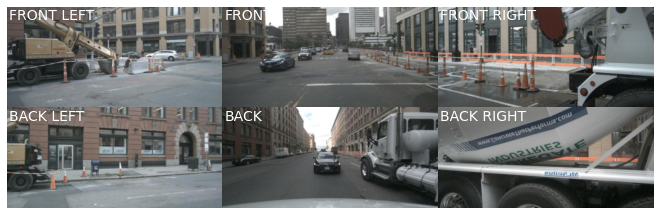

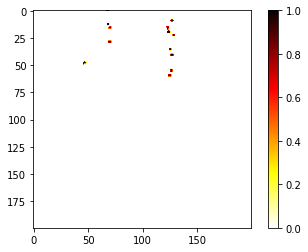

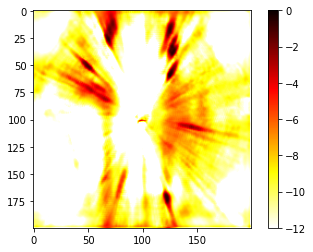

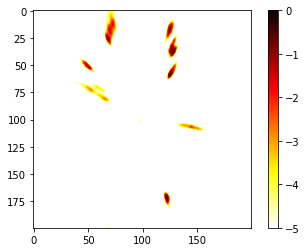

In [88]:
idx = 15
plot_img(idx//4, idx%4)

heatmap1 = plt.imshow(segm_ped_y[0, idx], cmap="hot_r") #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)
plt.show()

heatmap1 = plt.imshow(np.log(segm_ped_p[0, idx]), cmap="hot_r", vmin=-12, vmax=0) #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)
plt.savefig("res_fig1a_segm_log-12.pdf", bbox_inches='tight')

plt.show()


heatmap1 = plt.imshow(np.log(segm_ped_p[0, idx]), cmap="hot_r", vmin=-5, vmax=0) #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)

plt.savefig("res_fig1a_segm_log-5.pdf", bbox_inches='tight')


In [196]:
ys_front

[0, 0, 0, 0, 0, 0]

In [68]:
indices_test.shape

(4096,)

In [69]:
mask_full

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [105]:
len(cls)

7

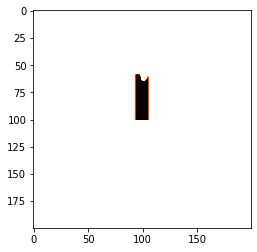

In [106]:
plt.imshow(np.sum([mask_full], axis=0), cmap="hot_r")

In [107]:
idx

4583

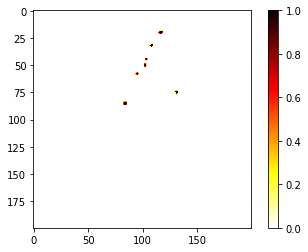

In [108]:
heatmap1 = plt.imshow(segm_ped_y[0, idx], cmap="hot_r") #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)

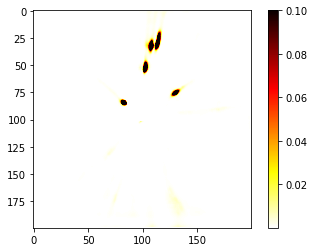

In [109]:
#plt.imshow(segm_ped_p[0, idx])
heatmap1 = plt.imshow(segm_ped_p[0, idx], cmap="hot_r", vmax=0.1) #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)

In [110]:
area_infront = np.array([[59,101],[94,106]])

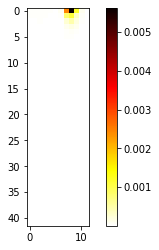

In [111]:
a = segm_ped_p[0, idx][area_infront[0,0]:area_infront[0,1], area_infront[1,0]:area_infront[1,1]]
heatmap1 = plt.imshow(a, cmap="hot_r") #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)

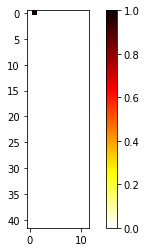

In [112]:
a = segm_ped_y[0, idx][area_infront[0,0]:area_infront[0,1], area_infront[1,0]:area_infront[1,1]]
heatmap1 = plt.imshow(a, cmap="hot_r") #, cmap='hot', interpolation='nearest')'
plt.colorbar(heatmap1)

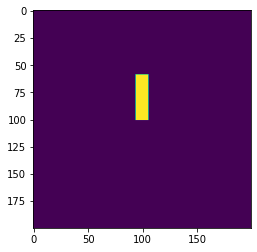

In [100]:
plt.imshow(mask_full)

In [101]:
len(ys_front)

1

In [102]:
np.sum(ys_front)

0

In [103]:
area_infront

array([[ 59, 101],
       [ 94, 106]])

In [104]:
#plt.imshow(background_segm)
#plt.xlim(89, 111)
#plt.ylim(100, 50)

(array([3.714e+03, 6.700e+01, 2.800e+01, 2.100e+01, 2.100e+01, 2.600e+01,
        2.600e+01, 3.800e+01, 2.600e+01, 1.500e+01, 1.200e+01, 1.300e+01,
        1.000e+01, 1.200e+01, 1.000e+01, 2.000e+00, 5.000e+00, 4.000e+00,
        1.000e+01, 2.000e+00, 1.000e+00, 3.000e+00, 4.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 3.000e+00, 2.000e+00, 2.000e+00, 4.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 2.000e+00, 2.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00]),
 array([0.00000000e+00, 3.07631099e-05, 6.15262199e-05, 9.22893298e-05,
        1.23052440e-04, 1.53815550e-04, 1.84578660e-04, 2.15341770e-04,
        2.46104880e-04, 2.76867989e-04, 3.07631099e-04, 3.38394209e-04,
        3.69157319e-04, 3.99920429e-04, 4.30683539e-04, 4.61446649e-04,
        4.92209759e-04, 5.22972869e-04, 5.53735979e-04, 5.84499089e-04,
        6.152621

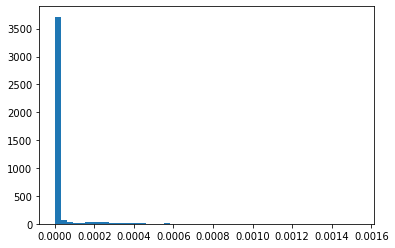

In [47]:
plt.hist(np.clip(prob_front_mean, 0, 1), bins=50)

In [20]:
np.quantile(prob_front, 0.9)

3.260328395056579

In [61]:
ys_front = np.array(ys_front)
prob_front = np.array(prob_front)
prob_front_max = np.array(prob_front_max)
prob_front_mean = np.array(prob_front_mean)

In [106]:
ys_front.sum()

58

(array([4.34e+03, 3.91e+02, 1.78e+02, 7.20e+01, 3.80e+01, 1.90e+01,
        2.50e+01, 1.10e+01, 5.00e+00, 8.00e+00, 5.00e+00, 9.00e+00,
        4.00e+00, 8.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 2.00e+00,
        1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00,
        1.00e+00]),
 array([0.        , 0.04918906, 0.09837812, 0.14756717, 0.19675623,
        0.24594529, 0.29513435, 0.3443234 , 0.39351246, 0.44270152,
        0.49189058, 0.54107964, 0.59026869, 0.63945775, 0.68864681,
        0.73783587, 0.78702492, 0.83621398, 0.88540304, 0.9345921 ,
        0.98378116, 1.03297021, 1.08215927, 1.13134833, 1.18053739,
        1.22972644]),
 <BarContainer object of 25 artists>)

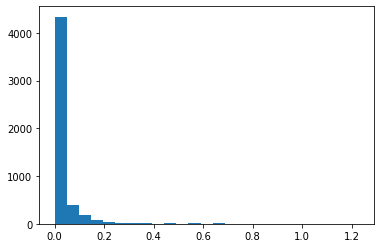

In [107]:
plt.hist(prob_cal_front, bins=25)


ECE_abs: 0.004729378556536676
[512, 512, 512, 512, 512, 512, 512, 512, 512, 511]
Conf: [0.0, 1.9291790132203862e-05, 0.0001794847453291923, 0.00036760396740710113, 0.0006473218880534208, 0.0011348116314315666, 0.002080225369522071, 0.004171575185217443, 0.009630185734646926, 0.06063304530074388]
Acc: [0.0, 0.001953125, 0.0, 0.0, 0.00390625, 0.009765625, 0.009765625, 0.013671875, 0.01953125, 0.0547945205479452]


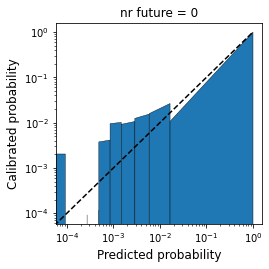

In [110]:
generate_rel_diagrams(np.clip(prob_front, 0, 1), ys_front, equal_size=True)

In [64]:
np.sum(ys_front)

51


ECE_abs: 0.06682600527158632
[410, 410, 410, 410, 410, 410, 409, 409, 409, 409]
Conf: [0.0, 0.0009088319339716104, 0.003645798502598565, 0.005777181066113483, 0.008436208175155753, 0.012778983505457805, 0.021907717112198972, 0.03737392203480917, 0.08309692396975639, 0.6168447492584891]
Acc: [0.0, 0.0, 0.0024390243902439024, 0.007317073170731708, 0.007317073170731708, 0.004878048780487805, 0.014669926650366748, 0.017114914425427872, 0.02689486552567237, 0.044009779951100246]


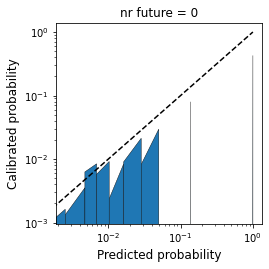

In [63]:
generate_rel_diagrams(np.clip(prob_cal_front, 0, 1), ys_front, equal_size=True)


ECE_abs: 0.08912106912421378
[410, 410, 410, 410, 410, 410, 409, 409, 409, 409]
Conf: [0.0, 9.711384812855887e-06, 4.0452780119333666e-05, 8.92499952098616e-05, 0.0001712007073986503, 0.00030875240669801557, 0.0006381237760845408, 0.0015252737011327829, 0.022005274613481243, 0.7779433413210591]
Acc: [0.0, 0.0024390243902439024, 0.0024390243902439024, 0.00975609756097561, 0.004878048780487805, 0.01707317073170732, 0.02444987775061125, 0.07334963325183375, 0.03667481662591687, 0.03178484107579462]


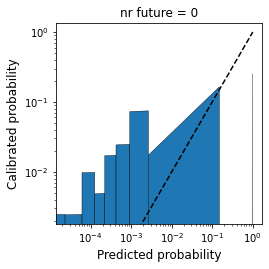

In [51]:
generate_rel_diagrams(np.clip(prob_front_max, 0, 1), ys_front, equal_size=True)


ECE_abs: 0.02023714184262721
[410, 410, 410, 410, 410, 410, 409, 409, 409, 409]
Conf: [0.0, 4.362849133293647e-09, 1.778280263086298e-08, 3.7923305072119114e-08, 7.49041936447828e-08, 1.373319742609714e-07, 2.684656567967435e-07, 5.892575843823593e-07, 3.968021192800115e-06, 0.00026059954904790385]
Acc: [0.0, 0.0, 0.007317073170731708, 0.007317073170731708, 0.004878048780487805, 0.01951219512195122, 0.02689486552567237, 0.061124694376528114, 0.04645476772616137, 0.029339853300733496]


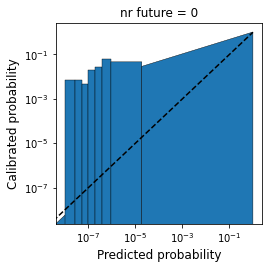

In [52]:
generate_rel_diagrams(np.clip(prob_front_mean, 0, 1), ys_front, equal_size=True)


ECE_abs: 0.17209285250531053
[2144, 234, 87, 35, 25, 25, 5, 16, 15, 405]
Conf: [0.02261145447608818, 0.14275124240689258, 0.2470979606245962, 0.3368352903216642, 0.4494186039806952, 0.5514433740066369, 0.6372742398336764, 0.7598515325403682, 0.838380955362945, 0.9990591493528346]
Acc: [0.013992537313432836, 0.04700854700854701, 0.034482758620689655, 0.0, 0.0, 0.0, 0.0, 0.125, 0.0, 0.02962962962962963]


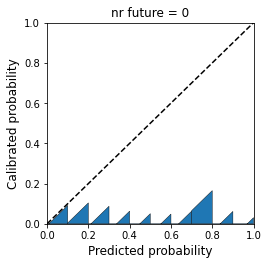

In [25]:
generate_rel_diagrams(np.clip(prob_cal_front, 0, 1), ys_front)

In [26]:
# TODO check how the coordinates relate? Is a correct area selected
# Dist means, in which format?

## Calibrated segm for GMM

In [29]:
nr_future = 0

if True:  # Skip if no need to rerun
    
    area_infront = np.array([[59,101],[94,106]])


    ys_front = []
    prob_front = []
    prob_cal_front = []
    
    prob_front_max = []
    prob_cal_front_max = []
    
    prob_front_mean = []
    prob_cal_front_mean = []
    
    indices = []


    for idx in range(0, segm_ped_p.shape[1]):
        
        #print(idx)

        if idx % 100 == 0:
            print(idx)

        segm_cal_full = np.zeros(shape=masks_cal[0].shape)
        center_cal_full = np.zeros(shape=masks_cal_c[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))
            
            segm_cal_2d[np.isnan(segm_cal_2d)] = 1/val_pixels
            segm_cal_2d = np.clip(segm_cal_2d, 1/val_pixels, 1)
            segm_cal_2d = segm_cal_2d.astype("float64")

            segm_cal_full[mask] = segm_cal_2d[mask]

        for model_c, mask_c in zip(models_cal_c, masks_cal_c):
            center_cal = model_c.predict(center_ped_p[nr_future, idx].flatten())
            center_cal_2d = center_cal.reshape(200,200)
            
            center_cal_2d[np.isnan(center_cal_2d)] = 1/val_pixels
            center_cal_2d = np.clip(center_cal_2d, 1/val_pixels, 1)
            center_cal_2d = center_cal_2d.astype("float64")

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))

            center_cal_full[mask_c] = center_cal_2d[mask_c]


        segm_p_new = segm_ped_p[nr_future, idx].copy()
        center_p_cal = center_cal_full.copy()
        #center_ped_p_new = center_ped_p[nr_future, idx].copy()
        segm_p_cal_new = segm_cal_full.copy()

        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_cal_new, segm_p_cal_new, center_p_cal, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        cls = get_clusters(segm_ped_y[0, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

            
        # Background of GMMs
        background_gmm = np.ones_like(segm_p_cal_new)
        


        if masks_gmm != None:
            
            for m in masks_gmm:
                background_gmm[m] = 0
                
            background_gmm = background_gmm.T
            
            for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

                #print(pred_cl)

                all_matches.append([[], [], [pr], [pr_cal], [dist.mean], [idx]])

                for n_cl, cl in enumerate(cls):
                    matches = np.sum(m[np.array(cl)[:, 0], np.array(cl)[:, 1]])
                    match_prob = matches/len(cl)

                    if matches != 0:
                        all_matches[i][0].append(n_cl)
                        all_matches[i][1].append(match_prob)                  
                
        # Get TPs and FNs
        TPs = []

        for am in all_matches:
            TPs += am[0]

        cl_nrs = np.arange(len(cls))
        FNs = cl_nrs[~np.in1d(cl_nrs, TPs)]
        
        mask_infront = background_gmm[area_infront[0,0]:area_infront[0,1], area_infront[1,0]:area_infront[1,1]]
        y_front = 0
        
        mask_full = np.zeros_like(segm_p_cal_new)
        mask_full[area_infront[0,0]:area_infront[0,1], area_infront[1,0]:area_infront[1,1]] = mask_infront
        
        for cl_id in FNs:
            cl = cls[cl_id]
            matches = np.sum(mask_full[np.array(cl)[:, 1], np.array(cl)[:, 0]])
            match_prob = matches/len(cl)
            
            if matches != 0:
                y_front = 1
        
        ys_front.append(y_front)
        prob_front.append(np.sum(mask_full*segm_p_new))
        prob_cal_front.append(np.sum(mask_full*segm_p_cal_new))
        indices.append(idx)
        
        #prob_front_max.append(np.max(mask_full*segm_p_new))
        #prob_cal_front_max.append(np.max(mask_full*segm_p_cal_new))
        
        #prob_front_mean.append(np.mean(mask_full*segm_p_new))
        #prob_cal_front_mean.append(np.mean(mask_full*segm_p_cal_new))
        
        # Check if any cls inside for MATCH
        # Get probs for masked area
    
    np.savez("results_undetected_uncertainty_6m_cal_09_27_22_pw.npz", p=np.array(prob_front), p_cal=np.array(prob_cal_front), y=np.array(ys_front), indices = np.array(indices))

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100


In [30]:
nr_future = 0

if True:  # Skip if no need to rerun
    
    area_infront = np.array([[59,101],[89,111]])


    ys_front = []
    prob_front = []
    prob_cal_front = []
    
    prob_front_max = []
    prob_cal_front_max = []
    
    prob_front_mean = []
    prob_cal_front_mean = []
    
    indices = []


    for idx in range(0, segm_ped_p.shape[1]):
        
        #print(idx)

        if idx % 100 == 0:
            print(idx)

        segm_cal_full = np.zeros(shape=masks_cal[0].shape)
        center_cal_full = np.zeros(shape=masks_cal_c[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))

            segm_cal_2d[np.isnan(segm_cal_2d)] = 1/val_pixels
            segm_cal_2d = np.clip(segm_cal_2d, 1/val_pixels, 1)
            segm_cal_2d = segm_cal_2d.astype("float64")

            segm_cal_full[mask] = segm_cal_2d[mask]

        for model_c, mask_c in zip(models_cal_c, masks_cal_c):
            center_cal = model_c.predict(center_ped_p[nr_future, idx].flatten())
            center_cal_2d = center_cal.reshape(200,200)
            
            center_cal_2d[np.isnan(center_cal_2d)] = 1/val_pixels
            center_cal_2d = np.clip(center_cal_2d, 1/val_pixels, 1)
            center_cal_2d = center_cal_2d.astype("float64")

            center_cal_full[mask_c] = center_cal_2d[mask_c]


        segm_p_new = segm_ped_p[nr_future, idx].copy()
        center_p_cal = center_cal_full.copy()
        #center_ped_p_new = center_ped_p[nr_future, idx].copy()
        segm_p_cal_new = segm_cal_full.copy()

        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_cal_new, segm_p_cal_new, center_p_cal, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        cls = get_clusters(segm_ped_y[0, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

            
        # Background of GMMs
        background_gmm = np.ones_like(segm_p_cal_new)
        


        if masks_gmm != None:
            
            for m in masks_gmm:
                background_gmm[m] = 0
                
            background_gmm = background_gmm.T
            
            for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

                #print(pred_cl)

                all_matches.append([[], [], [pr], [pr_cal], [dist.mean], [idx]])

                for n_cl, cl in enumerate(cls):
                    matches = np.sum(m[np.array(cl)[:, 0], np.array(cl)[:, 1]])
                    match_prob = matches/len(cl)

                    if matches != 0:
                        all_matches[i][0].append(n_cl)
                        all_matches[i][1].append(match_prob)                  
                
        # Get TPs and FNs
        TPs = []

        for am in all_matches:
            TPs += am[0]

        cl_nrs = np.arange(len(cls))
        FNs = cl_nrs[~np.in1d(cl_nrs, TPs)]
        
        mask_infront = background_gmm[area_infront[0,0]:area_infront[0,1], area_infront[1,0]:area_infront[1,1]]
        y_front = 0
        
        mask_full = np.zeros_like(segm_p_cal_new)
        mask_full[area_infront[0,0]:area_infront[0,1], area_infront[1,0]:area_infront[1,1]] = mask_infront
        
        for cl_id in FNs:
            cl = cls[cl_id]
            matches = np.sum(mask_full[np.array(cl)[:, 1], np.array(cl)[:, 0]])
            match_prob = matches/len(cl)
            
            if matches != 0:
                y_front = 1
        
        ys_front.append(y_front)
        prob_front.append(np.sum(mask_full*segm_p_new))
        prob_cal_front.append(np.sum(mask_full*segm_p_cal_new))
        indices.append(idx)
        
        #prob_front_max.append(np.max(mask_full*segm_p_new))
        #prob_cal_front_max.append(np.max(mask_full*segm_p_cal_new))
        
        #prob_front_mean.append(np.mean(mask_full*segm_p_new))
        #prob_cal_front_mean.append(np.mean(mask_full*segm_p_cal_new))
        
        # Check if any cls inside for MATCH
        # Get probs for masked area
    
    np.savez("results_undetected_uncertainty_10m_cal_09_27_22_pw.npz", p=np.array(prob_front), p_cal=np.array(prob_cal_front), y=np.array(ys_front), indices = np.array(indices))

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100


In [28]:
data_un2 = np.load("results_undetected_uncertainty_6m_cal_09_27_22.npz")

prob_front2 = data_un2["p"]
prob_cal_front2 = data_un2["p_cal"]
ys_front2 = data_un2["y"]


ECE_abs: 0.120513601569065
[2161, 37, 17, 6, 5, 14, 2, 5, 4, 277]
Conf: [0.006001238796105332, 0.14011717914086252, 0.251943513455676, 0.3518286385587637, 0.4586312639162176, 0.5331895401095974, 0.6567124159595696, 0.7516294064068015, 0.8449664175026448, 0.9994204592115156]
Acc: [0.008329477093937991, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02527075812274368]


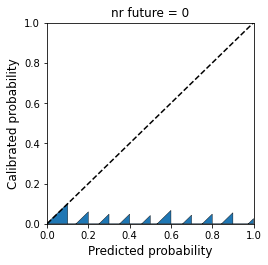

In [29]:
generate_rel_diagrams(np.clip(np.array(prob_front2), 0, 1), np.array(ys_front2))